In [26]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, norm
from scipy.optimize import minimize

### 1. Load Data

In [27]:
START_DATE = "2023-01-04"  

noc_df = pd.read_csv("../../data/Secteur_Aerospace/NOC.csv")
noc_df = noc_df[["Date", "Adj Close"]].copy()
noc_df.columns = ["Date", "X_t"]

bdraf_df = pd.read_csv("../../data/Secteur_Aerospace/BDRAF.csv")
bdraf_df = bdraf_df[["Date", "Adj Close"]].copy()
bdraf_df.columns = ["Date", "X_t"]

airpa_df = pd.read_csv("../../data/Secteur_Aerospace/AIR.PA.csv")
airpa_df = airpa_df[["Date", "Adj Close"]].copy()
airpa_df.columns = ["Date", "X_t"]

In [28]:
# NOC Dataset
noc_df[:]

,Date,X_t
0,2023-01-03,513.8915
1,2023-01-04,500.6907
2,2023-01-05,502.6594
3,2023-01-06,495.9068
4,2023-01-09,471.1695
...,...,...
766,2026-01-23,672.9500
767,2026-01-26,660.9700
768,2026-01-27,678.7400
769,2026-01-28,689.1300


In [29]:
# BDRAF Dataset
bdraf_df[:]

,Date,X_t
0,2023-01-03,39.20
1,2023-01-04,40.70
2,2023-01-05,40.30
3,2023-01-06,41.88
4,2023-01-09,42.00
...,...,...
766,2026-01-23,197.00
767,2026-01-26,197.00
768,2026-01-27,197.00
769,2026-01-28,197.00


### 2. Clean Data

In [30]:
noc_df["Date"] = pd.to_datetime(noc_df["Date"])
noc_df = noc_df[noc_df["Date"] >= pd.Timestamp(START_DATE)].copy()
noc_df = noc_df.sort_values("Date").dropna().reset_index(drop=True)
print(f"NOC Dataset shape: {noc_df.shape}")

bdraf_df["Date"] = pd.to_datetime(bdraf_df["Date"])
bdraf_df = bdraf_df[bdraf_df["Date"] >= pd.Timestamp(START_DATE)].copy()
bdraf_df = bdraf_df.sort_values("Date").dropna().reset_index(drop=True)
print(f"BDRAF Dataset shape: {bdraf_df.shape}")

NOC Dataset shape: (770, 2)
BDRAF Dataset shape: (770, 2)


### 3. Compute the Hanning Filter

$$
Y_t = \frac{1}{4} X_{t-1} + \frac{1}{2} X_t + \frac{1}{4} X_{t+1}
$$

In [31]:
noc_df["Y_t"] = (
    0.25 * noc_df["X_t"].shift(1) +
    0.50 * noc_df["X_t"] +
    0.25 * noc_df["X_t"].shift(-1)
)

bdraf_df["Y_t"] = (
    0.25 * bdraf_df["X_t"].shift(1) +
    0.50 * bdraf_df["X_t"] +
    0.25 * bdraf_df["X_t"].shift(-1)
)

# Drop first and last rows with NaN
noc_df = noc_df.dropna().reset_index(drop=True)
bdraf_df = bdraf_df.dropna().reset_index(drop=True)

**Plot Raw Series vs Filtered Series**

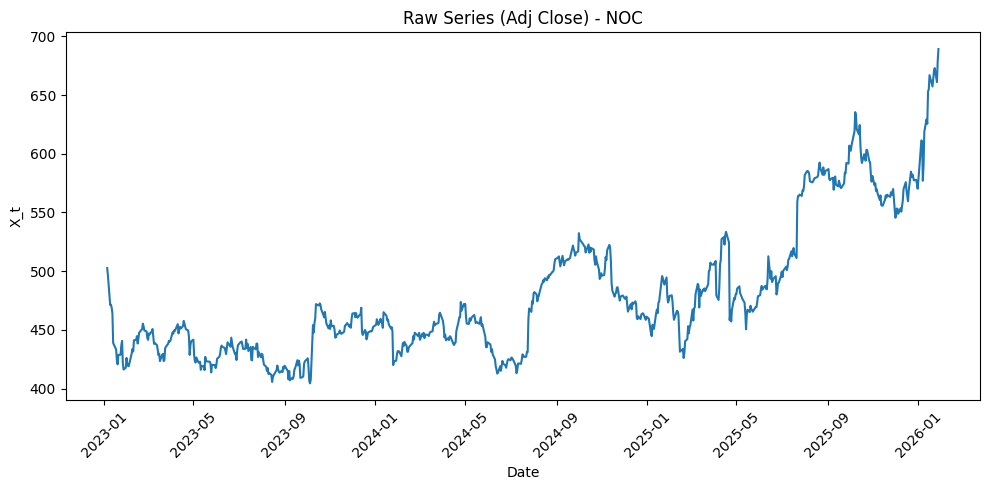

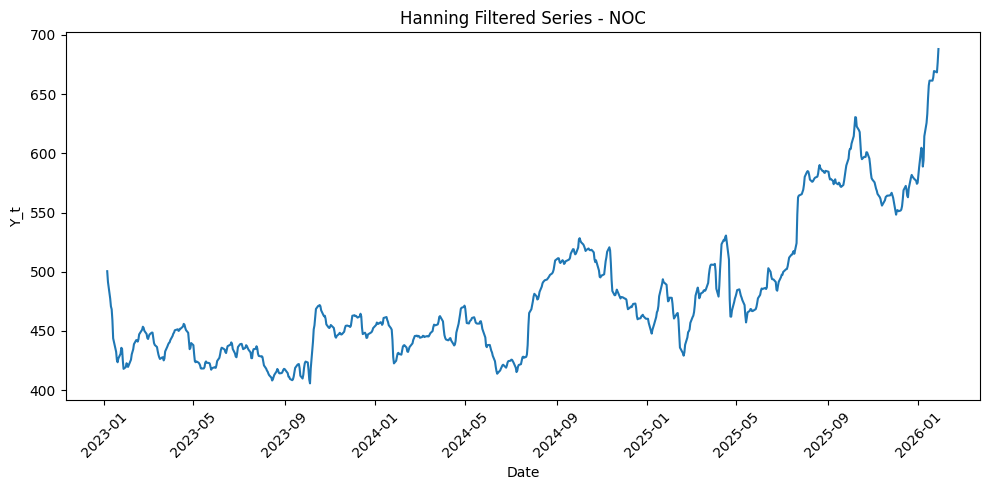

In [32]:
# NOC 
plt.figure(figsize=(10, 5))
plt.plot(noc_df["Date"], noc_df["X_t"])
plt.title("Raw Series (Adj Close) - NOC")
plt.xlabel("Date")
plt.ylabel("X_t")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(noc_df["Date"], noc_df["Y_t"])
plt.title("Hanning Filtered Series - NOC")
plt.xlabel("Date")
plt.ylabel("Y_t")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

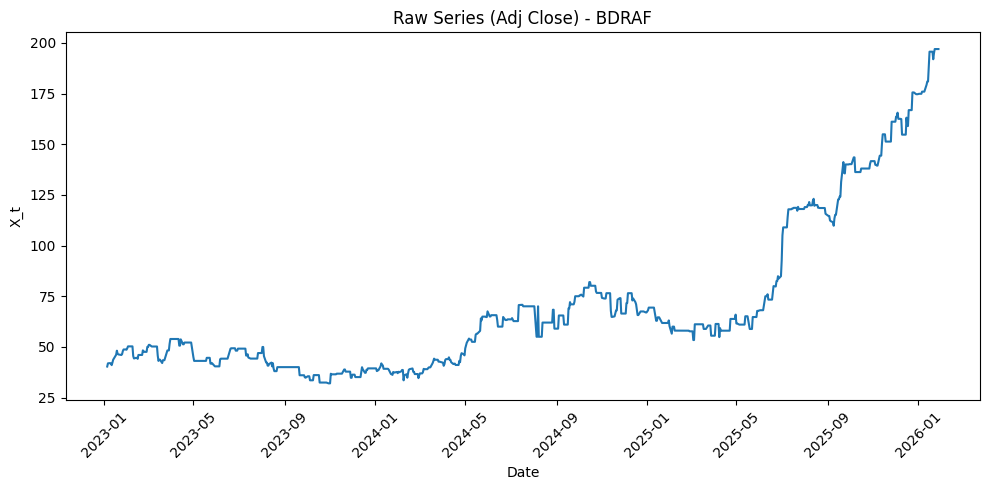

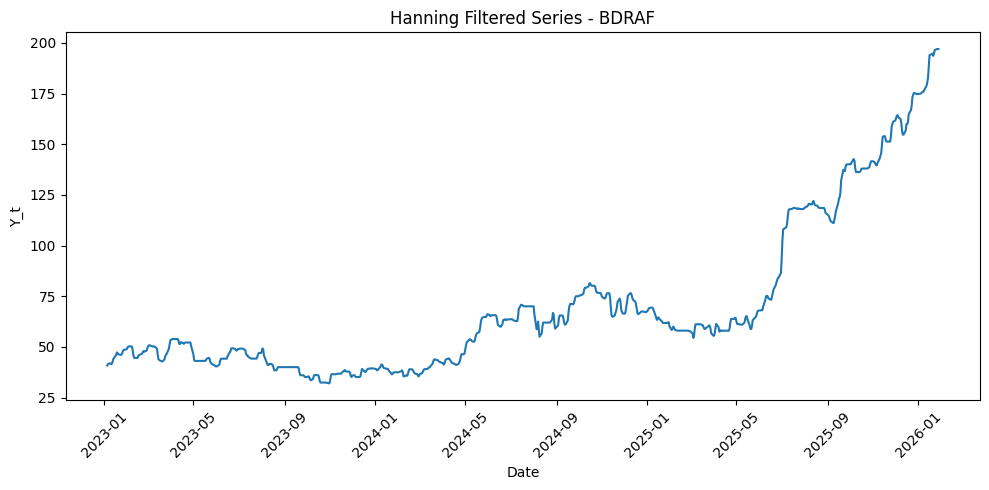

In [33]:
# BDRAF
plt.figure(figsize=(10, 5))
plt.plot(bdraf_df["Date"], bdraf_df["X_t"])
plt.title("Raw Series (Adj Close) - BDRAF")
plt.xlabel("Date")
plt.ylabel("X_t")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(bdraf_df["Date"], bdraf_df["Y_t"])
plt.title("Hanning Filtered Series - BDRAF")
plt.xlabel("Date")
plt.ylabel("Y_t")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## NOC Analysis

### 4. KS Scan Over k

In [34]:
Y_noc = noc_df["Y_t"].to_numpy()
n_noc = len(Y_noc)

k_values_noc = []
ks_stats_noc = []
p_values_noc = []

for k in range(30, n_noc - 29):
    sample1 = Y_noc[:k]
    sample2 = Y_noc[k:]
    stat, pval = ks_2samp(sample1, sample2)
    k_values_noc.append(k)
    ks_stats_noc.append(stat)
    p_values_noc.append(pval)

best_idx_noc = int(np.argmax(ks_stats_noc))
k_hat_noc = k_values_noc[best_idx_noc]
best_ks_noc = float(ks_stats_noc[best_idx_noc])
best_pval_noc = float(p_values_noc[best_idx_noc])
break_date_noc = noc_df.loc[k_hat_noc, "Date"]

print("\nBest rupture point from KS scan (NOC)")
print("k_hat      =", k_hat_noc)
print("break_date =", break_date_noc.date())
print("KS stat    =", best_ks_noc)
print("p-value    =", best_pval_noc)


Best rupture point from KS scan (NOC)
k_hat      = 636
break_date = 2025-07-22
KS stat    = 1.0
p-value    = 4.751232536633156e-152


**KS Scan Plot**

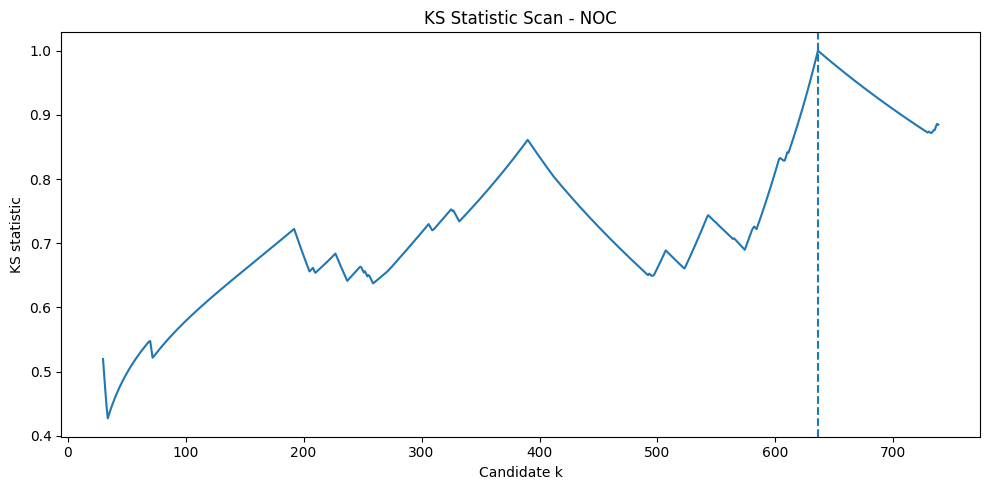

In [35]:
# KS Scan Plot
plt.figure(figsize=(10, 5))
plt.plot(k_values_noc, ks_stats_noc)
plt.axvline(k_hat_noc, linestyle="--")
plt.title("KS Statistic Scan - NOC")
plt.xlabel("Candidate k")
plt.ylabel("KS statistic")
plt.tight_layout()
plt.show()

Breakpoint Plot

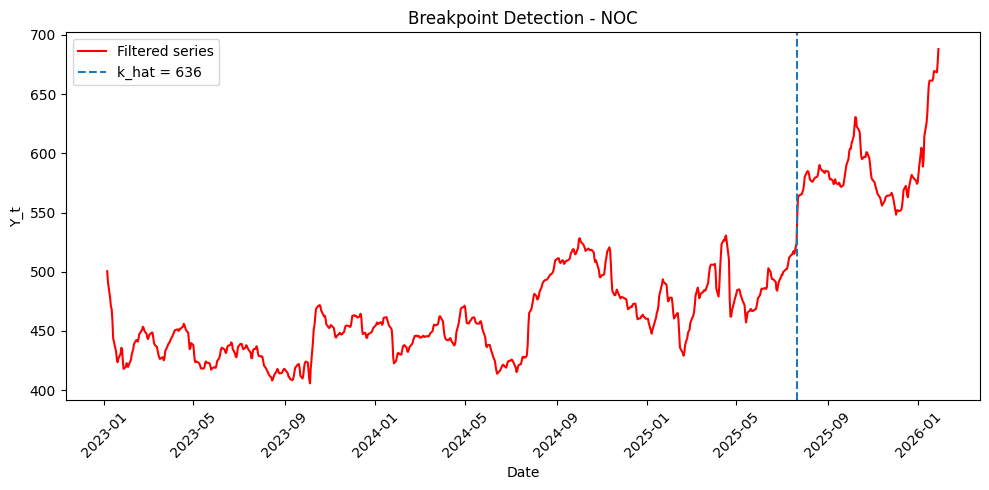

In [36]:
from turtle import color
plt.figure(figsize=(10, 5))
plt.plot(noc_df["Date"], noc_df["Y_t"], label="Filtered series", color='red')
plt.axvline(break_date_noc, linestyle="--", label=f"k_hat = {k_hat_noc}")
plt.title("Breakpoint Detection - NOC")
plt.xlabel("Date")
plt.ylabel("Y_t")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### 5. Split and Estimate Skew Normal Parameters

In [37]:
y1_noc = Y_noc[:k_hat_noc]
y2_noc = Y_noc[k_hat_noc:]

print("\nSegment sizes (NOC)")
print("Before rupture:", len(y1_noc))
print("After rupture :", len(y2_noc))

def skew_normal_pdf(x, mu, sigma, theta):
    z = (x - mu) / sigma
    return (2.0 / sigma) * norm.pdf(z) * norm.cdf(theta * z)

def neg_loglik_common_theta(params, y_left, y_right):
    mu1, log_sigma1, mu2, log_sigma2, theta = params
    sigma1 = np.exp(log_sigma1)
    sigma2 = np.exp(log_sigma2)
    if sigma1 <= 0 or sigma2 <= 0 or not np.isfinite(theta):
        return np.inf
    pdf1 = skew_normal_pdf(y_left, mu1, sigma1, theta)
    pdf2 = skew_normal_pdf(y_right, mu2, sigma2, theta)
    eps = 1e-12
    pdf1 = np.clip(pdf1, eps, None)
    pdf2 = np.clip(pdf2, eps, None)
    ll = np.sum(np.log(pdf1)) + np.sum(np.log(pdf2))
    return -ll


Segment sizes (NOC)
Before rupture: 636
After rupture : 132


In [38]:
# Initial values
mu1_init = float(np.mean(y1_noc))
mu2_init = float(np.mean(y2_noc))
sigma1_init = float(np.std(y1_noc, ddof=0))
sigma2_init = float(np.std(y2_noc, ddof=0))
sigma1_init = max(sigma1_init, 1e-3)
sigma2_init = max(sigma2_init, 1e-3)
theta_init = 0.0

x0 = np.array([mu1_init, np.log(sigma1_init), mu2_init, np.log(sigma2_init), theta_init])

result_noc = minimize(
    neg_loglik_common_theta,
    x0=x0,
    args=(y1_noc, y2_noc),
    method="L-BFGS-B"
)

if not result_noc.success:
    print("\nWarning: optimization did not fully converge (NOC).")
    print("Message:", result_noc.message)

mu1_hat_noc, log_sigma1_hat_noc, mu2_hat_noc, log_sigma2_hat_noc, theta_hat_noc = result_noc.x
sigma1_hat_noc = float(np.exp(log_sigma1_hat_noc))
sigma2_hat_noc = float(np.exp(log_sigma2_hat_noc))
mu1_hat_noc = float(mu1_hat_noc)
mu2_hat_noc = float(mu2_hat_noc)
theta_hat_noc = float(theta_hat_noc)

print("\nJoint MLE estimates with common theta (NOC)")
print("mu1    =", mu1_hat_noc)
print("sigma1 =", sigma1_hat_noc)
print("mu2    =", mu2_hat_noc)
print("sigma2 =", sigma2_hat_noc)
print("theta  =", theta_hat_noc)
print("NegLogLik =", float(result_noc.fun))


Joint MLE estimates with common theta (NOC)
mu1    = 457.7250746462264
sigma1 = 30.17045896084362
mu2    = 587.0125791666667
sigma2 = 29.103346132768525
theta  = 0.0
NegLogLik = 3701.462446841442


In [39]:
verdict_noc = "Reject H0" if best_pval_noc < 0.05 else "Fail to reject H0"
print("\nVerdict (NOC):", verdict_noc)


Verdict (NOC): Reject H0


#### Plot Segment Fits

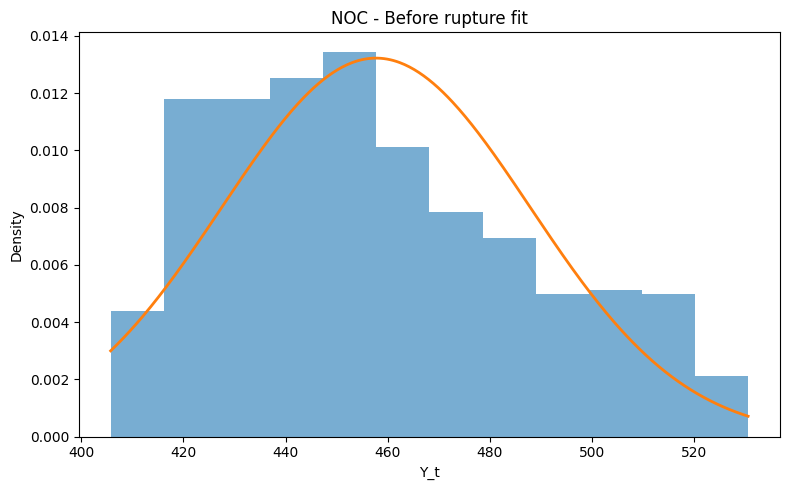

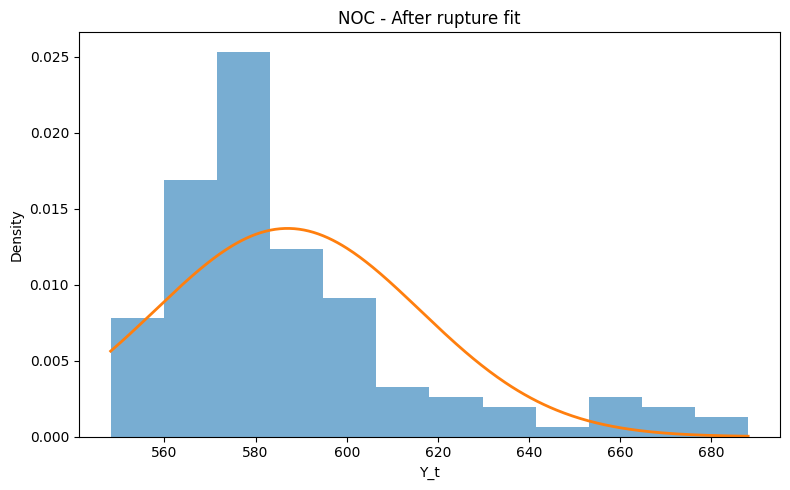

In [40]:
def plot_segment_fit(data, mu, sigma, theta, title):
    x_grid = np.linspace(np.min(data), np.max(data), 400)
    y_pdf = skew_normal_pdf(x_grid, mu, sigma, theta)
    plt.figure(figsize=(8, 5))
    plt.hist(data, bins=12, density=True, alpha=0.6)
    plt.plot(x_grid, y_pdf, linewidth=2)
    plt.title(title)
    plt.xlabel("Y_t")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

plot_segment_fit(y1_noc, mu1_hat_noc, sigma1_hat_noc, theta_hat_noc, "NOC - Before rupture fit")
plot_segment_fit(y2_noc, mu2_hat_noc, sigma2_hat_noc, theta_hat_noc, "NOC - After rupture fit")

#### Interpretion NOC

In [41]:
# NOC interpretation
def build_interpretation_short(company, k, date, ks, pval, verdict, mu1, sigma1, mu2, sigma2, theta):
    return (
        f"For {company}, the estimated rupture point is k_hat = {k} "
        f"({date.date()}). The KS statistic is {ks:.4f} and the "
        f"p-value is {pval:.4f}, so the decision is: {verdict}. "
        f"The joint MLE estimates are mu1 = {mu1:.4f}, sigma1 = {sigma1:.4f}, "
        f"mu2 = {mu2:.4f}, sigma2 = {sigma2:.4f}, theta = {theta:.4f}."
    )

interpretation_noc = build_interpretation_short(
    "NOC",
    k_hat_noc,
    break_date_noc,
    best_ks_noc,
    best_pval_noc,
    verdict_noc,
    mu1_hat_noc,
    sigma1_hat_noc,
    mu2_hat_noc,
    sigma2_hat_noc,
    theta_hat_noc
)
print(interpretation_noc)

For NOC, the estimated rupture point is k_hat = 636 (2025-07-22). The KS statistic is 1.0000 and the p-value is 0.0000, so the decision is: Reject H0. The joint MLE estimates are mu1 = 457.7251, sigma1 = 30.1705, mu2 = 587.0126, sigma2 = 29.1033, theta = 0.0000.


**Save Result as JSON -- NOC**

In [42]:
results_noc = {
    "company": "NOC",
    "name": "Northrop Grumman",
    "url": "https://fr.finance.yahoo.com/quote/NOC/profile",
    "k_hat": int(k_hat_noc),
    "bp_date": str(break_date_noc.date()),
    "D": float(best_ks_noc),
    "p_value": float(best_pval_noc),
    "reject_H0": best_pval_noc < 0.05,
    "verdict": verdict_noc,
    "mu1": float(mu1_hat_noc),
    "sigma1": float(sigma1_hat_noc),
    "mu2": float(mu2_hat_noc),
    "sigma2": float(sigma2_hat_noc),
    "theta": float(theta_hat_noc),
    "n1": len(y1_noc),
    "n2": len(y2_noc),
    "interpretation": interpretation_noc
}

with open("NOC.json", "w", encoding="utf-8") as f:
    json.dump(results_noc, f, indent=4, ensure_ascii=False)

## BDRAF Analysis

#### 4. KS Scan Over k

In [43]:
Y_bdraf = bdraf_df["Y_t"].to_numpy()
n_bdraf = len(Y_bdraf)

k_values_bdraf = []
ks_stats_bdraf = []
p_values_bdraf = []

for k in range(30, n_bdraf - 29):
    sample1 = Y_bdraf[:k]
    sample2 = Y_bdraf[k:]
    stat, pval = ks_2samp(sample1, sample2)
    k_values_bdraf.append(k)
    ks_stats_bdraf.append(stat)
    p_values_bdraf.append(pval)

best_idx_bdraf = int(np.argmax(ks_stats_bdraf))
k_hat_bdraf = k_values_bdraf[best_idx_bdraf]
best_ks_bdraf = float(ks_stats_bdraf[best_idx_bdraf])
best_pval_bdraf = float(p_values_bdraf[best_idx_bdraf])
break_date_bdraf = bdraf_df.loc[k_hat_bdraf, "Date"]

print("\nBest rupture point from KS scan (BDRAF)")
print("k_hat      =", k_hat_bdraf)
print("break_date =", break_date_bdraf.date())
print("KS stat    =", best_ks_bdraf)
print("p-value    =", best_pval_bdraf)


Best rupture point from KS scan (BDRAF)
k_hat      = 341
break_date = 2024-05-15
KS stat    = 1.0
p-value    = 5.542466799052602e-228


**KS Scan Plot and Breakpoint Plot k ∈ {10, ..., n-10}**

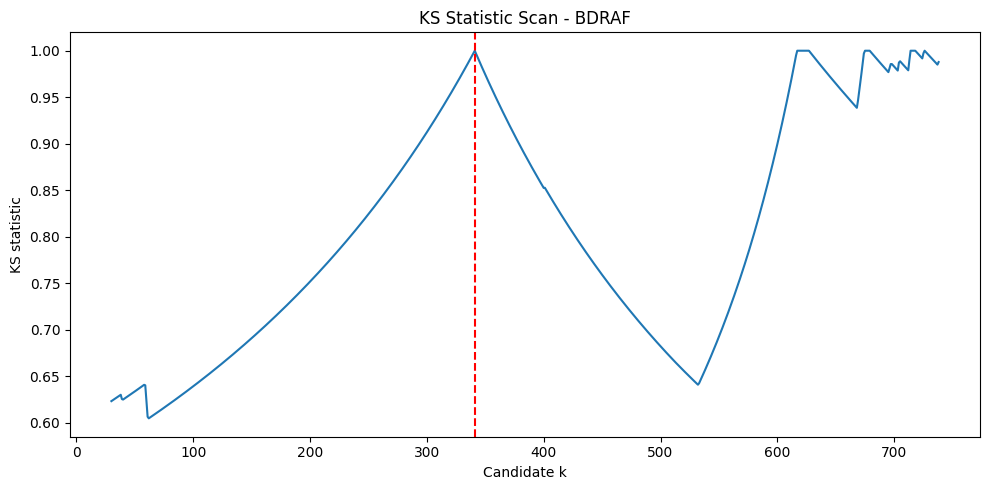

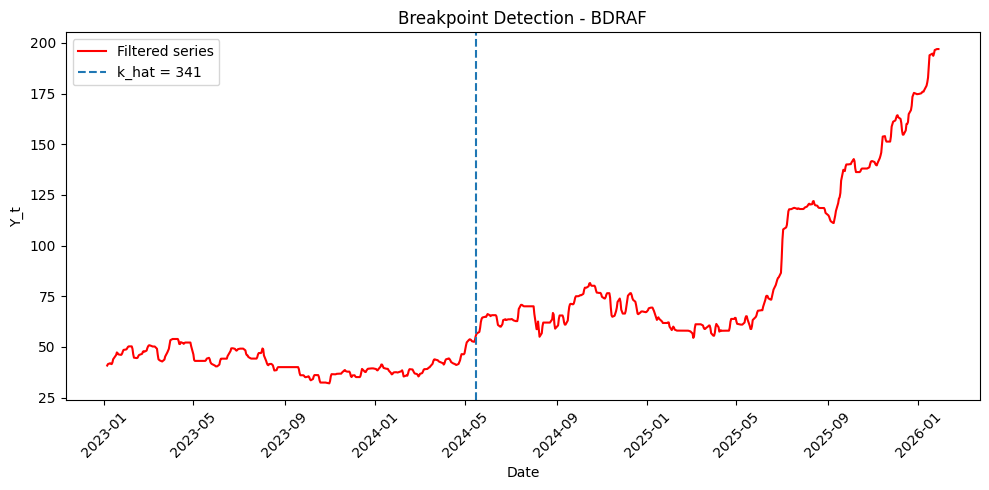

In [44]:
plt.figure(figsize=(10, 5))
plt.plot(k_values_bdraf, ks_stats_bdraf)
plt.axvline(k_hat_bdraf, linestyle="--", color='red')
plt.title("KS Statistic Scan - BDRAF")
plt.xlabel("Candidate k")
plt.ylabel("KS statistic")
plt.tight_layout()
plt.show()

# Breakpoint
plt.figure(figsize=(10, 5))
plt.plot(bdraf_df["Date"], bdraf_df["Y_t"], label="Filtered series", color='red')
plt.axvline(break_date_bdraf, linestyle="--", label=f"k_hat = {k_hat_bdraf}")
plt.title("Breakpoint Detection - BDRAF")
plt.xlabel("Date")
plt.ylabel("Y_t")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### 5. Split and Estimate Skew Normal Parameters

In [45]:
y1_bdraf = Y_bdraf[:k_hat_bdraf]
y2_bdraf = Y_bdraf[k_hat_bdraf:]

print("\nSegment sizes (BDRAF)")
print("Before rupture:", len(y1_bdraf))
print("After rupture :", len(y2_bdraf))


Segment sizes (BDRAF)
Before rupture: 341
After rupture : 427


In [46]:
# Initial values
mu1_init = float(np.mean(y1_bdraf))
mu2_init = float(np.mean(y2_bdraf))
sigma1_init = float(np.std(y1_bdraf, ddof=0))
sigma2_init = float(np.std(y2_bdraf, ddof=0))
sigma1_init = max(sigma1_init, 1e-3)
sigma2_init = max(sigma2_init, 1e-3)
theta_init = 0.0

x0 = np.array([mu1_init, np.log(sigma1_init), mu2_init, np.log(sigma2_init), theta_init])

result_bdraf = minimize(
    neg_loglik_common_theta,
    x0=x0,
    args=(y1_bdraf, y2_bdraf),
    method="L-BFGS-B"
)

if not result_bdraf.success:
    print("\nWarning: optimization did not fully converge (BDRAF).")
    print("Message:", result_bdraf.message)

mu1_hat_bdraf, log_sigma1_hat_bdraf, mu2_hat_bdraf, log_sigma2_hat_bdraf, theta_hat_bdraf = result_bdraf.x
sigma1_hat_bdraf = float(np.exp(log_sigma1_hat_bdraf))
sigma2_hat_bdraf = float(np.exp(log_sigma2_hat_bdraf))
mu1_hat_bdraf = float(mu1_hat_bdraf)
mu2_hat_bdraf = float(mu2_hat_bdraf)
theta_hat_bdraf = float(theta_hat_bdraf)

print("\nJoint MLE estimates with common theta (BDRAF)")
print("mu1    =", mu1_hat_bdraf)
print("sigma1 =", sigma1_hat_bdraf)
print("mu2    =", mu2_hat_bdraf)
print("sigma2 =", sigma2_hat_bdraf)
print("theta  =", theta_hat_bdraf)
print("NegLogLik =", float(result_bdraf.fun))


Joint MLE estimates with common theta (BDRAF)
mu1    = 42.44061583577712
sigma1 = 5.467601070023512
mu2    = 91.81793911007024
sigma2 = 38.871243403784305
theta  = 1.6377902575818667e-08
NegLogLik = 3231.977990566369


In [47]:
verdict_bdraf = "Reject H0" if best_pval_bdraf < 0.05 else "Fail to reject H0"
print("\nVerdict (BDRAF):", verdict_bdraf)


Verdict (BDRAF): Reject H0


**Plot Segment Fit**

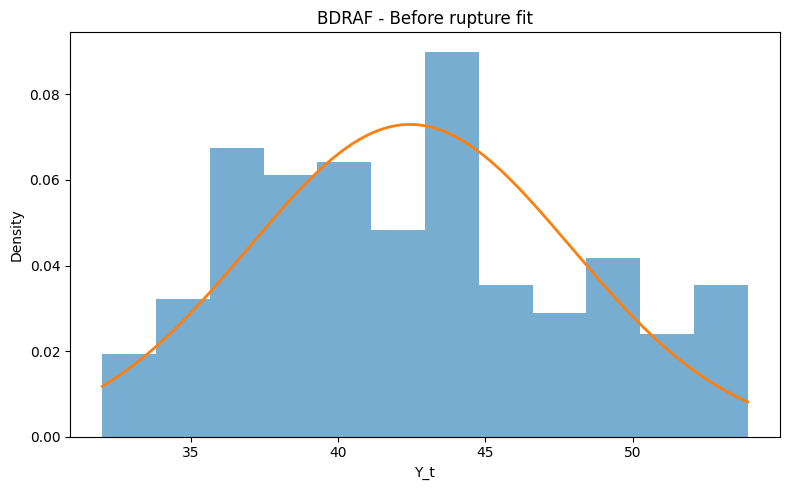

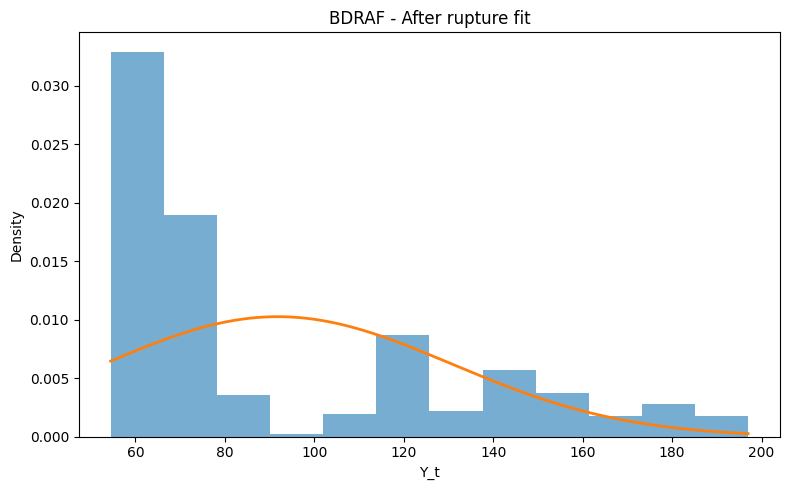

In [48]:
plot_segment_fit(y1_bdraf, mu1_hat_bdraf, sigma1_hat_bdraf, theta_hat_bdraf, "BDRAF - Before rupture fit")
plot_segment_fit(y2_bdraf, mu2_hat_bdraf, sigma2_hat_bdraf, theta_hat_bdraf, "BDRAF - After rupture fit")

### Interpretation

In [49]:
# BDRAF interpretation
interpretation_bdraf = build_interpretation_short(
    "BDRAF",
    k_hat_bdraf,
    break_date_bdraf,
    best_ks_bdraf,
    best_pval_bdraf,
    verdict_bdraf,
    mu1_hat_bdraf,
    sigma1_hat_bdraf,
    mu2_hat_bdraf,
    sigma2_hat_bdraf,
    theta_hat_bdraf
)
print(interpretation_bdraf)

For BDRAF, the estimated rupture point is k_hat = 341 (2024-05-15). The KS statistic is 1.0000 and the p-value is 0.0000, so the decision is: Reject H0. The joint MLE estimates are mu1 = 42.4406, sigma1 = 5.4676, mu2 = 91.8179, sigma2 = 38.8712, theta = 0.0000.


**Save Result as JSON BDRAF**

In [50]:
results_bdraf = {
    "company": "BDRAF",
    "name": "BAE Systems",
    "url": "https://fr.finance.yahoo.com/quote/BDRAF/profile",
    "k_hat": int(k_hat_bdraf),
    "bp_date": str(break_date_bdraf.date()),
    "D": float(best_ks_bdraf),
    "p_value": float(best_pval_bdraf),
    "reject_H0": best_pval_bdraf < 0.05,
    "verdict": verdict_bdraf,
    "mu1": float(mu1_hat_bdraf),
    "sigma1": float(sigma1_hat_bdraf),
    "mu2": float(mu2_hat_bdraf),
    "sigma2": float(sigma2_hat_bdraf),
    "theta": float(theta_hat_bdraf),
    "n1": len(y1_bdraf),
    "n2": len(y2_bdraf),
    "interpretation": interpretation_bdraf
}

with open("BDRAF.json", "w", encoding="utf-8") as f:
    json.dump(results_bdraf, f, indent=4, ensure_ascii=False)